# Pose Scoring Model Training

In [1]:
import numpy as np
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
import torch
from sklearn.model_selection import train_test_split
from services.ScoringService import ScoringService
from services.ClassifyingService import ClassifyingService
from services.VisualisationService import save_visualized_video
from repositories.MediapipeSegmentationRepository import MediapipeSegmentationRepository

### Configuration
This block defines constants for file paths, number of segments, and pose labels.

In [2]:
with open('config.json', 'r') as f:
    config = json.load(f)

handstand_model_config = config['models']['handstand']
classification_model_path = handstand_model_config['model_rel_path']
poses_config = handstand_model_config['poses']

# Create a mapping from pose_idx to pose_name for convenience
idx_to_pose_name = {}
for name, p_config in poses_config.items():
    idx_to_pose_name[p_config['pose_idx']] = name
    if 'sub_poses' in p_config and p_config['sub_poses']:
        for sub_name, sub_p_config in p_config['sub_poses'].items():
            idx_to_pose_name[sub_p_config['pose_idx']] = sub_name

pose_names = list(poses_config.keys()) # Original main pose names for classifier
pose_labels = {p['pose_idx']: [name] for name, p in poses_config.items() if 'model_rel_path' in p}

# Add sub-poses to pose_labels
for parent_pose, parent_config in poses_config.items():
    if 'sub_poses' in parent_config and parent_config['sub_poses']:
        for sub_pose_name, sub_pose_config in parent_config['sub_poses'].items():
            pose_labels[sub_pose_config['pose_idx']] = [sub_pose_name]

video_folder = "./dataset/videos/handstand"
pose_scores_csv = "./dataset/labels/beoordeling.csv"
pose_labels_csv = "./dataset/labels/pose_labels.csv"
skeletons_json = "./dataset/skeletons/handstand_cos_skeletons.json"

num_segments = 10

### Skeleton Feature Extraction
This block processes all videos in the `video_folder` to extract skeleton features using the `MediapipeSegmentationRepository`. The extracted features are saved to a JSON file. If the JSON file already exists, this step is skipped.

In [3]:
if not os.path.exists(skeletons_json):
    segmentation_repository = MediapipeSegmentationRepository()
    video_names = os.listdir(video_folder)
    videos_score_data = {}
    for video_name in tqdm(video_names):
        videos_score_data[video_name] = {}
        full_video_path = os.path.join(video_folder, video_name)
        frames, feature_tensor, mask = segmentation_repository.process_video_cosine_segments(full_video_path)
        videos_score_data[video_name]["features"] = [[segment[0] for segment in frame] + \
                                                     [segment[1] for segment in frame]\
                                                     for frame in feature_tensor.tolist()]
        videos_score_data[video_name]["mask"] = mask.tolist()
    with open(skeletons_json, 'w') as f:
        json.dump(videos_score_data, f, indent=4)
else:
    print(f"{skeletons_json} already exists. Skipping feature extraction.")

./dataset/skeletons/handstand_cos_skeletons.json already exists. Skipping feature extraction.


### Skeleton Feature Extraction Fit

In [4]:
def process_pose_labels(pose_labels_csv, skeletons_json):
    """
    Process pose labels and skeleton features.
    
    Returns:
        features: list of numpy arrays (num_frames, num_features)
        targets: list of numpy arrays (num_frames, num_poses) - one-hot encoded
        video_names: list of video names
    """
    
    pose_labels = pd.read_csv(pose_labels_csv)
    pose_names = list(pose_labels.columns[1:])  # [\'starting\', \'swing\', \'handstand\', \'landing\']
    num_poses = len(pose_names)
    
    with open(skeletons_json, 'r') as f:
        videos_score_data = json.load(f)
    
    features = []
    targets = []
    video_names = []
    
    for video_name, video_data in videos_score_data.items():
        cos_angles = np.array(video_data["features"])
        mask = np.array(video_data["mask"])
        num_frames = len(mask)
        
        # Get pose start frames for this video
        video_row = pose_labels[pose_labels["videoname"] == video_name]
        
        if video_row.empty:
            print(f"Warning: {video_name} not found in pose labels, skipping...")
            continue
        
        # Get start frames for each pose
        start_frames = []
        for pose_name in pose_names:
            frame = int(video_row[pose_name].values[0])
            start_frames.append(frame)
        
        # Process start frames (handle -1 cases)
        start_frames = process_start_frames(start_frames, num_frames)
        
        # Generate pose sequence for each frame
        pose_sequence = generate_pose_sequence(start_frames, num_frames, num_poses)
        
        # Find actual start frame (first non -1 original frame, or processed start)
        actual_start = find_actual_start(start_frames)
        
        # Cut from actual start
        cos_angles = cos_angles[actual_start:]
        mask = mask[actual_start:]
        pose_sequence = pose_sequence[actual_start:]
        
        # Apply mask
        valid_indices = mask.astype(bool)
        cos_angles = cos_angles[valid_indices]
        pose_sequence = pose_sequence[valid_indices]
        
        if len(cos_angles) > 0:
            features.append(cos_angles)
            targets.append(pose_sequence)
            video_names.append(video_name)
        else:
            print(f"Warning: {video_name} has no valid frames after masking, skipping...")
    
    return features, targets, video_names, pose_names

In [5]:
features, targets, video_names, pose_names = process_pose_labels(pose_labels_csv, skeletons_json)
x_train, x_test, y_train, y_test = train_test_split(features, targets, test_size=0.2)

num_classes = targets[0].shape[1]
classifier = ClassifyingService(
    num_classes=num_classes,
    window_size=24,
    hidden_size=32,
    num_layers=3,
    dropout=0.5,
    batch_size=256,
    epochs=200,
    patience=64,
    class_names=("Starting", "Swing", "Handstand", "Landing"),
    device="cuda:0",
    augment=True,
    augment_scale_range=(0.99, 1.00),
    use_joint_attention=True,
    use_temporal_attention=True)

classifier.fit(x_train, y_train, x_test, y_test)
classifier.save_model(classification_model_path)

accuracy, report = classifier.evaluate(x_test, y_test, return_report=True)
pprint(report, indent=4)
sns.lineplot(classifier.history)

NameError: name 'process_start_frames' is not defined

### Pose Label Processing Functions
This block defines helper functions to process pose labels from the CSV file and align them with the skeleton data. These functions handle the logic for creating one-hot encoded pose sequences for each video.

In [ ]:
def process_start_frames(start_frames, num_frames):
    """
    Handle -1 cases in start frames.
    
    Rules:
    - If -1 is first: discard, start from next valid pose's frame
    - If -1 is after existing pose AND is the last pose: give 20 frames to prev pose
    - If -1 is in the middle: skip that pose (inherit from previous)
    """
    processed = start_frames.copy()
    num_poses = len(processed)
    
    # Find first valid (non -1) index
    first_valid_idx = -1
    for i, frame in enumerate(processed):
        if frame != -1:
            first_valid_idx = i
            break
    
    # If all are -1, return as is (will be handled later)
    if first_valid_idx == -1:
        return processed
    
    # Handle leading -1s: set them to -1 (will be cut later)
    # The actual start will be the first valid frame
    
    # Handle trailing -1s
    last_valid_idx = -1
    for i in range(num_poses - 1, -1, -1):
        if processed[i] != -1:
            last_valid_idx = i
            break
    
    # If last pose is -1 and there's a valid pose before it
    # Give 20 extra frames to last valid pose (handled in sequence generation)
    
    # Handle middle -1s: they will be skipped in sequence generation
    
    return processed


def find_actual_start(start_frames):
    """Find the first valid start frame"""
    for frame in start_frames:
        if frame != -1:
            return frame
    return 0


def generate_pose_sequence(start_frames, num_frames, num_poses):
    """
    Generate one-hot encoded pose sequence for each frame.
    
    Returns:
        pose_sequence: numpy array (num_frames, num_poses)
    """
    pose_sequence = np.zeros((num_frames, num_poses), dtype=np.float32)
    
    # Build list of (start_frame, pose_id) for valid poses
    valid_poses = []
    for pose_id, start_frame in enumerate(start_frames):
        if start_frame != -1:
            valid_poses.append((start_frame, pose_id))
    
    if not valid_poses:
        # No valid poses, return zeros
        return pose_sequence
    
    # Sort by start frame
    valid_poses.sort(key=lambda x: x[0])
    
    # Find last valid pose for -1 handling at end
    last_valid_idx = -1
    for i in range(len(start_frames) - 1, -1, -1):
        if start_frames[i] != -1:
            last_valid_idx = i
            break
    
    # Check if there are trailing -1s
    has_trailing_invalid = last_valid_idx < len(start_frames) - 1
    
    # Fill pose sequence
    for i, (start_frame, pose_id) in enumerate(valid_poses):
        # Determine end frame
        if i < len(valid_poses) - 1:
            # End at next pose's start frame
            end_frame = valid_poses[i + 1][0]
        else:
            # Last valid pose
            if has_trailing_invalid:
                # Give only 20 frames if there are trailing -1s
                end_frame = min(start_frame + 20, num_frames)
            else:
                # Fill to end
                end_frame = num_frames
        
        # Fill one-hot
        pose_sequence[start_frame:end_frame, pose_id] = 1.0
    
    return pose_sequence

### Scoring Data Preparation
This block prepares the data for training the scoring models. It loads the skeleton features and pose labels, reads the scores from the CSV file, and then creates feature-target pairs for each pose. The features are the sequences of joint data for frames belonging to a pose, and the target is the calculated score for that pose in a specific video.

In [ ]:
features, targets, video_names, _ = process_pose_labels(pose_labels_csv, skeletons_json)
scores_df = pd.read_csv(pose_scores_csv)

def prepare_scoring_data(features, targets, video_names, scores_df, poses_config, num_segments):
    # Initialize features and targets for all poses and sub-poses
    all_pose_indices = []
    for pose_name, pose_config in poses_config.items():
        all_pose_indices.append(pose_config['pose_idx'])
        if 'sub_poses' in pose_config and pose_config['sub_poses']:
            for sub_pose_name, sub_pose_config in pose_config['sub_poses'].items():
                all_pose_indices.append(sub_pose_config['pose_idx'])
    
    features_per_pose = {i: [] for i in all_pose_indices}
    targets_per_pose = {i: [] for i in all_pose_indices}

    for video_idx, video_name in enumerate(video_names):
        video_scores = scores_df[scores_df["video_name"] == video_name]
        if video_scores.empty:
            continue

        video_features = features[video_idx]
        video_targets = targets[video_idx]
        pose_indices = np.argmax(video_targets, axis=1)

        for pose_name, pose_config in poses_config.items():
            pose_id = pose_config['pose_idx']
            pose_specific_features = video_features[pose_indices == pose_id]
            
            if len(pose_specific_features) > 0:
                # If it's a parent pose with sub-poses, prepare data for sub-poses
                if 'sub_poses' in pose_config and pose_config['sub_poses']:
                    for sub_pose_name, sub_pose_config in pose_config['sub_poses'].items():
                        sub_pose_id = sub_pose_config['pose_idx']
                        segment_mask = sub_pose_config.get('segment_mask')
                        
                        # Apply segment mask to features
                        if segment_mask:
                            # Features are (n_frames, n_segments * 2)
                            # First half is x, second half is y
                            num_coords = len(segment_mask)
                            masked_features = np.hstack([
                                pose_specific_features[:, np.array(segment_mask)],
                                pose_specific_features[:, num_segments + np.array(segment_mask)]
                            ])
                        else:
                            masked_features = pose_specific_features
                            
                        features_per_pose[sub_pose_id].append(masked_features)
                        
                        # Target score for sub-pose is based on parent pose's score column
                        # This mapping needs to be defined based on the exercise
                        score_labels = []
                        if sub_pose_name == 'Back Position':
                            score_labels = ['lichaamshouding']
                        elif sub_pose_name == 'Arms Position':
                             score_labels = ['handplaatsing']
                        
                        if not score_labels:
                            continue
                            
                        mean_score = video_scores[score_labels].mean(axis=1).values[0]
                        num_frames = len(masked_features)
                        target_scores_for_sequence = []
                        for frame_idx in range(num_frames):
                            scaler = 1 - abs((frame_idx+1) - (num_frames * 0.5)) / num_frames
                            target_scores_for_sequence.append([mean_score*scaler] * (len(segment_mask) if segment_mask else num_segments))
                        targets_per_pose[sub_pose_id].append(np.array(target_scores_for_sequence))
                
                # If it's a regular pose, prepare data as before
                elif 'model_rel_path' in pose_config:
                    features_per_pose[pose_id].append(pose_specific_features)
                    
                    # Determine which score columns to use from beoordeling.csv
                    # This mapping needs to be defined based on the exercise
                    score_labels_map = {
                        'Starting': ['beginpositie'],
                        'Swing': ['opzwaai'],
                        'Landing': ['landing']
                    }
                    score_labels = score_labels_map.get(pose_name, [])
                    
                    if not score_labels:
                        continue
                        
                    mean_score = video_scores[score_labels].mean(axis=1).values[0]
                    num_frames = len(pose_specific_features)
                    target_scores_for_sequence = []
                    for frame_idx in range(num_frames):
                        scaler = 1 - abs((frame_idx+1) - (num_frames * 0.5)) / num_frames
                        target_scores_for_sequence.append([mean_score*scaler] * num_segments)
                    targets_per_pose[pose_id].append(np.array(target_scores_for_sequence))
                    
    return features_per_pose, targets_per_pose

features_per_pose, targets_per_pose = prepare_scoring_data(features, targets, video_names, scores_df, poses_config, num_segments)


### Train Scoring Models
This block trains a separate regression model for each pose to predict its score. It iterates through each pose, prepares the data, trains a `ScoringService` model, and saves the weights. Training metrics are plotted for each model.

--- Training Scoring Model for Pose: Starting (0) ---
Created 1373 training samples from 42 sequences
Created 359 validation samples from 11 sequences


Training:  40%|████      | 80/200 [00:18<00:28,  4.22it/s, Loss: 0.0480 | Val Loss: 0.0691]


Early stopping at epoch 81

Training History:


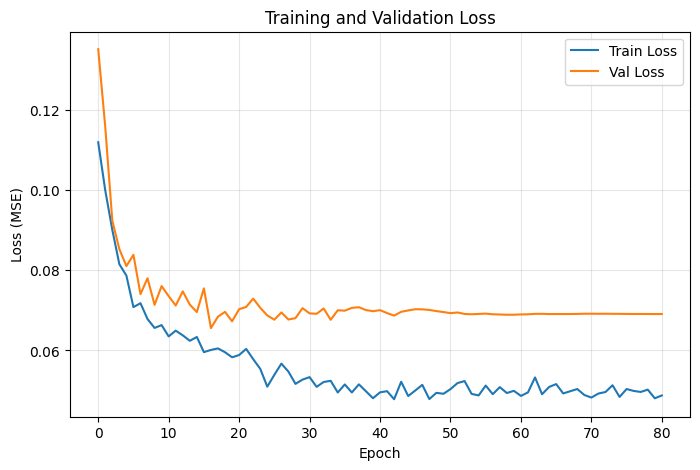

Model saved to ./model_weights/scoring_model0/scoring_model_pose_0.pth
Scoring model for pose 0 saved to ./model_weights/scoring_model0/scoring_model_pose_0.pth
--- Training Scoring Model for Pose: Swing (1) ---
Created 1248 training samples from 57 sequences
Created 410 validation samples from 15 sequences


Training:  44%|████▍     | 89/200 [00:18<00:22,  4.93it/s, Loss: 0.0256 | Val Loss: 0.0317]



Early stopping at epoch 90

Training History:


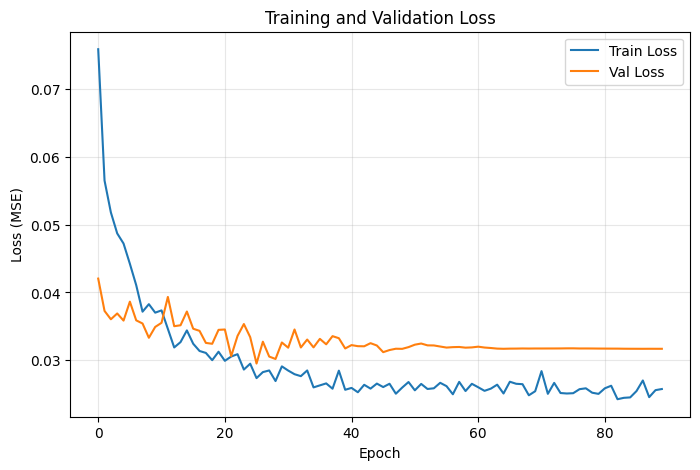

Model saved to ./model_weights/scoring_model0/scoring_model_pose_1.pth
Scoring model for pose 1 saved to ./model_weights/scoring_model0/scoring_model_pose_1.pth
--- Training Scoring Model for Pose: Back Position (4) ---
Created 2617 training samples from 56 sequences
Created 907 validation samples from 15 sequences


Training:  33%|███▎      | 66/200 [00:28<00:57,  2.34it/s, Loss: 0.0948 | Val Loss: 0.1204]


Early stopping at epoch 67

Training History:


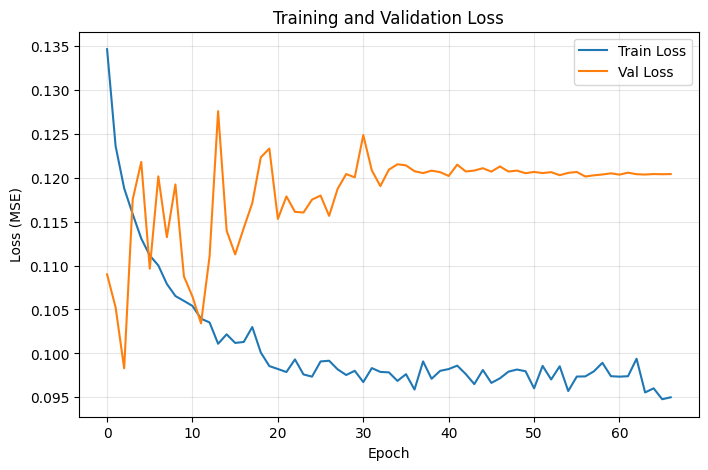

Model saved to ./model_weights/scoring_model0/scoring_model_pose_3.pth
Scoring model for pose 4 saved to ./model_weights/scoring_model0/scoring_model_pose_3.pth
--- Training Scoring Model for Pose: Arms Position (5) ---
Created 2821 training samples from 56 sequences
Created 703 validation samples from 15 sequences


Training:  32%|███▏      | 64/200 [00:31<01:06,  2.05it/s, Loss: 0.0243 | Val Loss: 0.0225]


Early stopping at epoch 65

Training History:


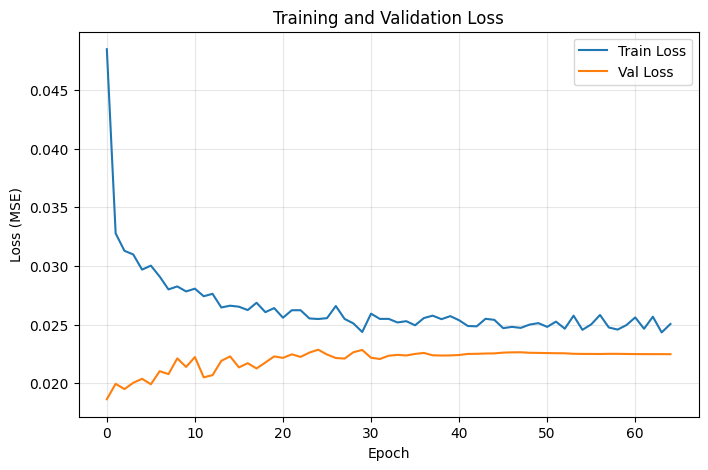

Model saved to ./model_weights/scoring_model0/scoring_model_pose_4.pth
Scoring model for pose 5 saved to ./model_weights/scoring_model0/scoring_model_pose_4.pth
--- Training Scoring Model for Pose: Landing (3) ---
Created 1046 training samples from 57 sequences
Created 352 validation samples from 15 sequences


Training:  34%|███▎      | 67/200 [00:11<00:23,  5.60it/s, Loss: 0.0545 | Val Loss: 0.0737]



Early stopping at epoch 68

Training History:


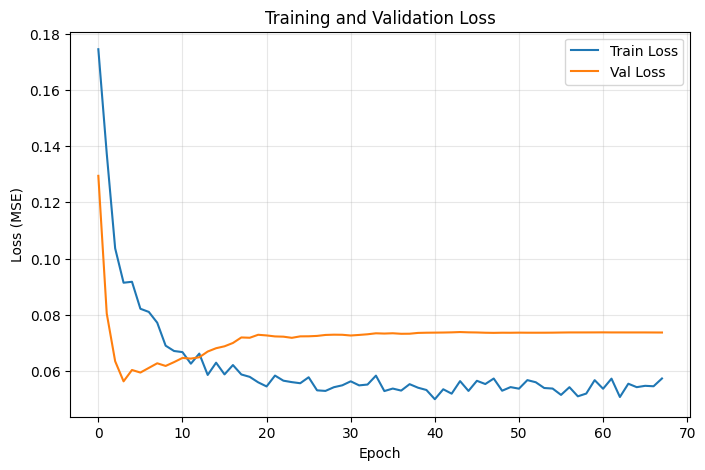

Model saved to ./model_weights/scoring_model0/scoring_model_pose_5.pth
Scoring model for pose 3 saved to ./model_weights/scoring_model0/scoring_model_pose_5.pth
--- All scoring models trained ---


In [ ]:
def train_scoring_model(pose_name, pose_config):
    pose_id = pose_config['pose_idx']
    print(f"--- Training Scoring Model for Pose: {pose_name} ({pose_id}) ---")
    
    if pose_id not in features_per_pose or not features_per_pose[pose_id]:
        print(f"No data available for pose {pose_name} ({pose_id}). Skipping.")
        return
        
    # Split data
    x_train, x_test, y_train, y_test = train_test_split(
        features_per_pose[pose_id], targets_per_pose[pose_id], test_size=0.2)
    
    num_outputs = y_train[0].shape[1]
    input_size = x_train[0].shape[1]

    # Create and train the model
    scorer = ScoringService(
        window_size=2,
        hidden_size=64,
        num_layers=4,
        dropout=0.5,
        batch_size=64,
        epochs=200,
        patience=64,
        device="cuda:0",
        augment=True,
        augment_scale_range=(0.97, 1.03),
        use_joint_attention=True,
        use_temporal_attention=True,
        num_outputs=num_outputs) 
    
    # Manually set input_size since it depends on the masked features
    scorer.input_size = input_size
    
    scorer.fit(x_train, y_train, x_test, y_test)
    
    print("\nTraining History:")
    scorer.plot_history()
    
    # Save model
    model_save_path = pose_config['model_rel_path']
    scorer.save_model(model_save_path)
    print(f"Scoring model for pose {pose_id} saved to {model_save_path}")

for pose_name, pose_config in poses_config.items():
    # If it's a parent pose, train models for sub-poses
    if 'sub_poses' in pose_config and pose_config['sub_poses']:
        for sub_pose_name, sub_pose_config in pose_config['sub_poses'].items():
            train_scoring_model(sub_pose_name, sub_pose_config)
    # If it's a regular pose with a model path, train it
    elif 'model_rel_path' in pose_config:
        train_scoring_model(pose_name, pose_config)

print("--- All scoring models trained ---")

### Process Test Video and Predict Scores
This block demonstrates how to use the trained models to analyze a test video. It first uses a pre-trained pose classification model to identify pose segments in the video. Then, for each segment, it uses the corresponding scoring model (trained in the previous block) to predict a score. The final output is a set of annotations for each frame, including the predicted pose and the score for the current segment.

In [5]:
test_video_path = "./dataset/videos/test/video_2026-01-16_10-25-40.mp4"

# Load pre-trained pose classifier
classifier = ClassifyingService(
    num_classes=4,
    input_size=20,
    window_size=24,
    hidden_size=32,
    num_layers=3,
    dropout=0.5,
    batch_size=256,
    epochs=200,
    patience=64,
    class_names=("Starting", "Swing", "Handstand", "Landing"),
    device="cuda:0",
    augment=True,
    augment_scale_range=(0.99, 1.00),
    use_joint_attention=True,
    use_temporal_attention=True)

classifier.load_model("./model_weights/gruClassifier7821.pth")

# Load scoring models
scoring_models = {}
for pose_name_key, pose_config in poses_config.items():
    if 'sub_poses' in pose_config and pose_config['sub_poses']:
        # Parent pose, no direct model, will average children's scores
        # Store sub-pose configs for later use
        for sub_pose_name_key, sub_pose_config in pose_config['sub_poses'].items():
            sub_pose_id = sub_pose_config['pose_idx']
            sub_model_path = sub_pose_config['model_rel_path']
            
            # Determine input_size and num_outputs for sub-pose model
            segment_mask = sub_pose_config.get('segment_mask')
            sub_input_size = len(segment_mask) * 2 if segment_mask else num_segments * 2
            sub_num_outputs = len(segment_mask) if segment_mask else num_segments
            
            if os.path.exists(sub_model_path):
                scorer = ScoringService(
                    window_size=2,
                    hidden_size=64,
                    num_layers=4,
                    dropout=0.5,
                    device="cuda:0",
                    use_joint_attention=True,
                    use_temporal_attention=True,
                    num_outputs=sub_num_outputs)
                scorer.input_size = sub_input_size # Set input_size before loading
                scorer.load_model(sub_model_path)
                scoring_models[sub_pose_id] = {
                    'model': scorer, 
                    'config': sub_pose_config, 
                    'parent_id': pose_config['pose_idx']
                }
    elif 'model_rel_path' in pose_config:
        pose_id = pose_config['pose_idx']
        model_path = pose_config['model_rel_path']
        
        # Determine input_size and num_outputs for regular pose model
        # Assume full segments for regular poses if no mask is specified
        input_size_regular = num_segments * 2
        num_outputs_regular = num_segments

        if os.path.exists(model_path):
            scorer = ScoringService(
                window_size=2,
                hidden_size=64,
                num_layers=4,
                dropout=0.5,
                device="cuda:0",
                use_joint_attention=True,
                use_temporal_attention=True,
                num_outputs=num_outputs_regular) 
            scorer.input_size = input_size_regular # Set input_size before loading
            scorer.load_model(model_path)
            scoring_models[pose_id] = {
                'model': scorer, 
                'config': pose_config, 
                'parent_id': None
            }

# Process test video
segmentation_repo = MediapipeSegmentationRepository()
# Make sure to process the *full* frames for visualization, not just the masked ones
all_frames_data, feature_tensor, mask = segmentation_repo.process_video_cosine_segments(test_video_path)

# Features for prediction should be from the masked frames
video_features = [[segment[0] for segment in frame] + [segment[1] for segment in frame] for frame in feature_tensor[mask].tolist()]

# Predict poses for the valid (masked) frames
predictions, probabilities = classifier.predict_frames([video_features])
predicted_poses = predictions[0]

# --- Process segments, get scores, and prepare annotations ---
# Annotations should correspond to the original number of frames
frame_annotations = [{} for _ in range(len(all_frames_data))]
valid_frame_indices = np.where(mask)[0] # Indices of frames that were not skipped

print("--- Segment Scores ---")

all_scores_overall = [] # To store all individual scores for the overall average

if len(predicted_poses) > 0:
    # Use config to get pose names mapping, including sub-poses
    pose_id_to_name = {pose_config['pose_idx']: name for name, pose_config in poses_config.items()}
    for parent_pose_name, parent_pose_config in poses_config.items():
        if 'sub_poses' in parent_pose_config and parent_pose_config['sub_poses']:
            for sub_pose_name, sub_pose_config in parent_pose_config['sub_poses'].items():
                pose_id_to_name[sub_pose_config['pose_idx']] = sub_pose_name

    current_pose_id = predicted_poses[0]
    segment_start_idx = 0 # Index within the predicted_poses array
    
    for i in range(1, len(predicted_poses)):
        if predicted_poses[i] != current_pose_id:
            # End of a segment
            segment_end_idx = i
            
            # Get features for the current segment
            segment_full_features = np.array(video_features[segment_start_idx:segment_end_idx])
            
            # Check if current_pose_id is a parent pose from config (has sub_poses)
            is_parent_pose = False
            parent_pose_config_found = None
            for name, cfg in poses_config.items():
                if cfg['pose_idx'] == current_pose_id and 'sub_poses' in cfg and cfg['sub_poses']:
                    is_parent_pose = True
                    parent_pose_config_found = cfg
                    break

            if is_parent_pose:
                # Calculate parent score as mean of child scores
                child_scores = []
                for sub_pose_name, sub_pose_config in parent_pose_config_found['sub_poses'].items():
                    sub_pose_id = sub_pose_config['pose_idx']
                    segment_mask = sub_pose_config.get('segment_mask')
                    
                    # Apply segment mask to features for this sub-pose
                    if segment_mask:
                        masked_sub_features = np.hstack([
                            segment_full_features[:, np.array(segment_mask)],
                            segment_full_features[:, num_segments + np.array(segment_mask)]
                        ])
                    else:
                        masked_sub_features = segment_full_features
                    
                    if sub_pose_id in scoring_models and len(masked_sub_features) > 0:
                        sub_scorer = scoring_models[sub_pose_id]['model']
                        sub_scores_per_frame = sub_scorer.predict_frames([masked_sub_features])[0]
                        child_scores.append(sub_scores_per_frame.mean()) # Mean score for this sub-pose segment
                        all_scores_overall.extend(list(sub_scores_per_frame.flatten())) # Add individual sub-scores to overall list

                        # Annotate sub-pose scores for frames within the parent segment
                        for j in range(segment_start_idx, segment_end_idx):
                            original_frame_idx = valid_frame_indices[j]
                            frame_sub_segment_scores = sub_scores_per_frame[j - segment_start_idx]
                            avg_frame_sub_score = frame_sub_segment_scores.mean()
                            
                            # Store for parent score calculation and individual sub-pose visualization
                            if 'sub_pose_scores' not in frame_annotations[original_frame_idx]:
                                frame_annotations[original_frame_idx]['sub_pose_scores'] = {}
                            frame_annotations[original_frame_idx]['sub_pose_scores'][sub_pose_name] = avg_frame_sub_score
                
                if child_scores:
                    overall_segment_score = np.mean(child_scores)
                    print(f"Segment: {idx_to_pose_name.get(current_pose_id, 'Unknown'):<10} | Frames: {valid_frame_indices[segment_start_idx]}-{valid_frame_indices[segment_end_idx-1]} | Score: {overall_segment_score:.3f} (Mean of sub-poses)")
                    
                    # Store parent score for visualization
                    for j in range(segment_start_idx, segment_end_idx):
                        original_frame_idx = valid_frame_indices[j]
                        frame_annotations[original_frame_idx]['label'] = f'{idx_to_pose_name.get(current_pose_id, "Unknown")} | Score: {overall_segment_score:.2f}'

            elif current_pose_id in scoring_models and len(segment_full_features) > 0:
                # Regular pose with a direct model
                scorer_info = scoring_models[current_pose_id]
                scorer_model = scorer_info['model']
                segment_scores_per_frame = scorer_model.predict_frames([segment_full_features])[0]
                all_scores_overall.extend(list(segment_scores_per_frame.flatten())) # Add individual scores to overall list
                
                overall_segment_score = segment_scores_per_frame.mean()
                print(f"Segment: {idx_to_pose_name.get(current_pose_id, 'Unknown'):<10} | Frames: {valid_frame_indices[segment_start_idx]}-{valid_frame_indices[segment_end_idx-1]} | Score: {overall_segment_score:.3f}")

                for j in range(segment_start_idx, segment_end_idx):
                    original_frame_idx = valid_frame_indices[j]
                    frame_segment_scores = segment_scores_per_frame[j - segment_start_idx]
                    avg_frame_score = frame_segment_scores.mean()
                    
                    frame_annotations[original_frame_idx]['label'] = f'{idx_to_pose_name.get(current_pose_id, "Unknown")} | Score: {avg_frame_score:.2f}'
                    frame_annotations[original_frame_idx]['segment_scores'] = {k: v for k, v in enumerate(frame_segment_scores)}
            
            # Start of new segment
            current_pose_id = predicted_poses[i]
            segment_start_idx = i

    # Process the last segment (after the loop)
    segment_end_idx = len(predicted_poses)
    segment_full_features = np.array(video_features[segment_start_idx:segment_end_idx])

    is_parent_pose = False
    parent_pose_config_found = None
    for name, cfg in poses_config.items():
        if cfg['pose_idx'] == current_pose_id and 'sub_poses' in cfg and cfg['sub_poses']:
            is_parent_pose = True
            parent_pose_config_found = cfg
            break

    if is_parent_pose:
        child_scores = []
        for sub_pose_name, sub_pose_config in parent_pose_config_found['sub_poses'].items():
            sub_pose_id = sub_pose_config['pose_idx']
            segment_mask = sub_pose_config.get('segment_mask')
            
            if segment_mask:
                masked_sub_features = np.hstack([
                    segment_full_features[:, np.array(segment_mask)],
                    segment_full_features[:, num_segments + np.array(segment_mask)]
                ])
            else:
                masked_sub_features = segment_full_features
            
            if sub_pose_id in scoring_models and len(masked_sub_features) > 0:
                sub_scorer = scoring_models[sub_pose_id]['model']
                sub_scores_per_frame = sub_scorer.predict_frames([masked_sub_features])[0]
                child_scores.append(sub_scores_per_frame.mean())
                all_scores_overall.extend(list(sub_scores_per_frame.flatten()))

                for j in range(segment_start_idx, segment_end_idx):
                    original_frame_idx = valid_frame_indices[j]
                    frame_sub_segment_scores = sub_scores_per_frame[j - segment_start_idx]
                    avg_frame_sub_score = frame_sub_segment_scores.mean()
                    
                    if 'sub_pose_scores' not in frame_annotations[original_frame_idx]:
                        frame_annotations[original_frame_idx]['sub_pose_scores'] = {}
                    frame_annotations[original_frame_idx]['sub_pose_scores'][sub_pose_name] = avg_frame_sub_score
        
        if child_scores:
            overall_segment_score = np.mean(child_scores)
            print(f"Segment: {idx_to_pose_name.get(current_pose_id, 'Unknown'):<10} | Frames: {valid_frame_indices[segment_start_idx]}-{valid_frame_indices[segment_end_idx-1]} | Score: {overall_segment_score:.3f} (Mean of sub-poses)")
            
            for j in range(segment_start_idx, segment_end_idx):
                original_frame_idx = valid_frame_indices[j]
                frame_annotations[original_frame_idx]['label'] = f'{idx_to_pose_name.get(current_pose_id, "Unknown")} | Score: {overall_segment_score:.2f}'

    elif current_pose_id in scoring_models and len(segment_full_features) > 0:
        scorer_info = scoring_models[current_pose_id]
        scorer_model = scorer_info['model']
        segment_scores_per_frame = scorer_model.predict_frames([segment_full_features])[0]
        all_scores_overall.extend(list(segment_scores_per_frame.flatten()))
        
        overall_segment_score = segment_scores_per_frame.mean()
        print(f"Segment: {idx_to_pose_name.get(current_pose_id, 'Unknown'):<10} | Frames: {valid_frame_indices[segment_start_idx]}-{valid_frame_indices[segment_end_idx-1]} | Score: {overall_segment_score:.3f}")

        for j in range(segment_start_idx, segment_end_idx):
            original_frame_idx = valid_frame_indices[j]
            frame_segment_scores = segment_scores_per_frame[j - segment_start_idx]
            avg_frame_score = frame_segment_scores.mean()
            
            frame_annotations[original_frame_idx]['label'] = f'{idx_to_pose_name.get(current_pose_id, "Unknown")} | Score: {avg_frame_score:.2f}'
            frame_annotations[original_frame_idx]['segment_scores'] = {k: v for k, v in enumerate(frame_segment_scores)}

if all_scores_overall:
    print(f"Total Score: {np.mean(all_scores_overall):.3f}")
else:
    print("Total Score: N/A (No scores calculated)")
print("----------------------")

Model loaded from ./model_weights/gruClassifier7821.pth
Model loaded from ./model_weights/scoring_model0/scoring_model_pose_0.pth with input_size 20
Model loaded from ./model_weights/scoring_model0/scoring_model_pose_1.pth with input_size 20
Model loaded from ./model_weights/scoring_model0/scoring_model_pose_3.pth with input_size 10
Model loaded from ./model_weights/scoring_model0/scoring_model_pose_4.pth with input_size 10
Model loaded from ./model_weights/scoring_model0/scoring_model_pose_5.pth with input_size 20


I0000 00:00:1768912236.409473   85970 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1768912236.425412   87891 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1768912236.655907   87880 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768912237.783241   87881 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


--- Segment Scores ---
Segment: Starting   | Frames: 0-22 | Score: 0.019
Segment: Swing      | Frames: 23-34 | Score: 0.918
Segment: Handstand  | Frames: 35-116 | Score: 0.810 (Mean of sub-poses)
Segment: Landing    | Frames: 117-128 | Score: 0.688
Total Score: 0.667
----------------------


### Visualize Results
This block saves a new video with the predicted pose labels and scores annotated on each frame. This provides a clear visual representation of the model's performance on the test video.

In [4]:
output_video_path = "./dataset/videos/test/test_scored.mp4"
save_visualized_video(output_video_path, 
                      all_frames_data, 
                      test_video_path,
                      frame_annotations=frame_annotations)